In [1]:
import tensorflow as tf

print("=" * 50)
print("TensorFlow Version:", tf.__version__)
print("=" * 50)

try:
    # Try to detect and initialize TPU
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
    print("TPU DETECTED")
    print(f"  - Running on TPU: {tpu.master()}")
    
    # Connect to the TPU cluster
    tf.config.experimental_connect_to_cluster(tpu)
    # Initialize the TPU system
    tf.tpu.experimental.initialize_tpu_system(tpu)
    
    # Create TPU Strategy
    strategy = tf.distribute.TPUStrategy(tpu)
    print(f"  - Number of TPU Cores: {strategy.num_replicas_in_sync}")

except ValueError:
    # Fallback to GPU or CPU if TPU is not found
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print("No TPU found - Running on GPU")
        strategy = tf.distribute.MirroredStrategy()
    else:
        print("No TPU or GPU found - Running on CPU")
        strategy = tf.distribute.get_strategy()

print("=" * 50)

2026-05-09 09:15:22.499071: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778318122.704437      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778318122.760228      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778318123.230785      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778318123.230863      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778318123.230873      57 computation_placer.cc:177] computation placer alr

TensorFlow Version: 2.19.0
No TPU found - Running on GPU
INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0', '/job:localhost/replica:0/task:0/device:GPU:1')


I0000 00:00:1778318149.605550      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778318149.611379      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [2]:
!pip install opendatasets -q

In [3]:
import opendatasets as od

od.download("https://www.kaggle.com/datasets/ismailpromus/skin-diseases-image-dataset")
od.download("https://www.kaggle.com/datasets/nayanchaure/acne-dataset")

print("Download complete!")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:

  abdelazizalhussien


Your Kaggle Key:

  ········


Dataset URL: https://www.kaggle.com/datasets/ismailpromus/skin-diseases-image-dataset


...

Your Kaggle Key:

  ········


Dataset URL: https://www.kaggle.com/datasets/nayanchaure/acne-dataset


100%|██████████| 167M/167M [00:01<00:00, 104MB/s]  



Download complete!


In [4]:
import os, random, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.preprocessing.image import img_to_array, load_img

warnings.filterwarnings("ignore")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

CONFIG = {
    "data_dirs"     : [
        "./skin-diseases-image-dataset",
        "./acne-dataset",
    ],
    "img_size"      : (224, 224),
    "batch_size"    : 64,
    "phase1_epochs" : 30,
    "dropout_rate"  : 0.4,
    "train_ratio"   : 0.70,
    "val_ratio"     : 0.15,
    "test_ratio"    : 0.15,
    "model_path"    : "derma_model.keras",
    "num_classes"   : None,
}

print("Imports and config ready.")
print(f"  TensorFlow : {tf.version}")
print(f"  GPU        : {bool(tf.config.list_physical_devices('GPU'))}")

Imports and config ready.
  TensorFlow : <module 'tensorflow._api.v2.version' from '/usr/local/lib/python3.12/dist-packages/tensorflow/_api/v2/version/__init__.py'>
  GPU        : True


In [5]:
# ============================================================
# LABEL MERGING: Atopic Dermatitis → Eczema
# Based on confusion matrix analysis showing heavy mutual
# confusion (0.19 misclassification rate) between these two
# clinically overlapping conditions.
# ============================================================

MERGE_MAP = {
    "Atopic Dermatitis": "Eczema",   # merge into Eczema
}

def apply_merge(label: str) -> str:
    return MERGE_MAP.get(label, label)

print("Label merge map:")
for src, tgt in MERGE_MAP.items():
    print(f"  {src!r} → {tgt!r}")


Label merge map:
  'Atopic Dermatitis' → 'Eczema'


In [6]:
import re

def clean_label(folder_name: str) -> str:
    name = re.sub(r"^\d+[\.\-\s]+", "", folder_name).strip()
    name = re.sub(r"[\s\-]+[\d\.]+k?$", "", name).strip()
    name = re.sub(r"\s*\([^)]+\)", "", name).strip()
    name = re.sub(r"\s+(pictures|and)\s+.*$", "", name, flags=re.IGNORECASE).strip()
    return name


def load_dataset_paths(data_dirs: list) -> pd.DataFrame:
    allowed_exts = {".jpg", ".jpeg"}
    records = []

    for data_dir in data_dirs:
        data_dir = Path(data_dir)
        if not data_dir.exists():
            print(f"WARNING: Directory not found, skipping: {data_dir}")
            continue
        for class_folder in sorted(data_dir.rglob("*")):
            if not class_folder.is_dir():
                continue
            label = clean_label(class_folder.name)
            label = apply_merge(label)
            for img_path in class_folder.iterdir():
                if img_path.suffix.lower() not in allowed_exts:
                    continue
                if any(kw in img_path.name.lower()
                       for kw in ["segmentation", "mask", "seg", "_mask"]):
                    continue
                records.append({"path": str(img_path), "label": label})

    df = pd.DataFrame(records)
    df = df.sample(frac=1, random_state=SEED).reset_index(drop=True)
    return df


def split_dataset(df: pd.DataFrame, cfg: dict):
    val_test_ratio     = cfg["val_ratio"] + cfg["test_ratio"]
    val_ratio_adjusted = cfg["val_ratio"] / val_test_ratio

    train_df, temp_df = train_test_split(
        df, test_size=val_test_ratio, stratify=df["label"], random_state=SEED
    )
    val_df, test_df = train_test_split(
        temp_df, test_size=1 - val_ratio_adjusted,
        stratify=temp_df["label"], random_state=SEED
    )
    return (train_df.reset_index(drop=True),
            val_df.reset_index(drop=True),
            test_df.reset_index(drop=True))


df = load_dataset_paths(CONFIG["data_dirs"])  # <-- uses the list, no more NameError

class_names           = sorted(df["label"].unique().tolist())
CONFIG["num_classes"] = len(class_names)
label2idx             = {name: idx for idx, name in enumerate(class_names)}
idx2label             = {idx: name for name, idx in label2idx.items()}

print(f"Total images : {len(df):,}")
print(f"Classes ({CONFIG['num_classes']}) : {class_names}\n")
print("Class distribution:")
print(df["label"].value_counts().to_string())

train_df, val_df, test_df = split_dataset(df, CONFIG)

print(f"\nSplit complete")
print(f"  Train : {len(train_df):,} images")
print(f"  Val   : {len(val_df):,}  images")
print(f"  Test  : {len(test_df):,}  images")

Total images : 28,933
Classes (10) : ['Acne', 'Basal Cell Carcinoma', 'Benign Keratosis-like Lesions', 'Eczema', 'Melanocytic Nevi', 'Melanoma', 'Psoriasis', 'Seborrheic Keratoses', 'Tinea Ringworm Candidiasis', 'Warts Molluscum']

Class distribution:
label
Melanocytic Nevi                 7970
Basal Cell Carcinoma             3323
Melanoma                         3140
Eczema                           2934
Warts Molluscum                  2103
Benign Keratosis-like Lesions    2079
Psoriasis                        2055
Seborrheic Keratoses             1847
Acne                             1780
Tinea Ringworm Candidiasis       1702

Split complete
  Train : 20,253 images
  Val   : 4,340  images
  Test  : 4,340  images


In [7]:
# ============================================================
# SECTION 1b - CLASS WEIGHTS
# Computed from train split only, then manually boosted for
# underperforming classes identified in confusion matrix.
#
# Psoriasis: recall=0.38  → boost ×2.0
# Eczema (merged): recall=0.50 → boost ×1.5
# Tinea Ringworm Candidiasis: recall=0.64 → boost ×1.3
# Warts Molluscum: recall=0.59 → boost ×1.3
# Seborrheic Keratoses: recall=0.70 → boost ×1.2
# ============================================================

y_train_integers = train_df["label"].map(label2idx).values

cw_array = compute_class_weight(
    class_weight = "balanced",
    classes      = np.unique(y_train_integers),
    y            = y_train_integers,
)
class_weight_dict = dict(enumerate(cw_array))

# Manual boost multipliers for hard/underperforming classes
BOOST = {
    "Psoriasis"                  : 2.0,
    "Eczema"                     : 1.5,   # merged class (was Atopic+Eczema)
    "Tinea Ringworm Candidiasis" : 1.3,
    "Warts Molluscum"            : 1.3,
    "Seborrheic Keratoses"       : 1.2,
    "Benign Keratosis-like Lesions": 1.2,
}

for idx, name in idx2label.items():
    if name in BOOST:
        class_weight_dict[idx] *= BOOST[name]

print("Class weights (with boost):")
for idx, name in idx2label.items():
    boost_tag = f"  ← ×{BOOST[name]}" if name in BOOST else ""
    print(f"  [{idx}] {name:40s} : {class_weight_dict[idx]:.4f}{boost_tag}")


Class weights (with boost):
  [0] Acne                                     : 1.6254
  [1] Basal Cell Carcinoma                     : 0.8707
  [2] Benign Keratosis-like Lesions            : 1.6704  ← ×1.2
  [3] Eczema                                   : 1.4790  ← ×1.5
  [4] Melanocytic Nevi                         : 0.3630
  [5] Melanoma                                 : 0.9214
  [6] Psoriasis                                : 2.8149  ← ×2.0
  [7] Seborrheic Keratoses                     : 1.8796  ← ×1.2
  [8] Tinea Ringworm Candidiasis               : 2.2107  ← ×1.3
  [9] Warts Molluscum                          : 1.7886  ← ×1.3


In [8]:
# ============================================================
# SECTION 1c - FOCAL LOSS
#
# Replaces categorical cross-entropy to:
#   1. Focus training on hard/misclassified examples
#   2. Down-weight the large number of easy correct predictions
#      from dominant classes (e.g. Melanocytic Nevi)
#
# gamma=2.0  : standard focusing parameter
# alpha=0.25 : balancing factor (used with class weights)
# ============================================================

class SparseFocalLoss(tf.keras.losses.Loss):
    """
    Focal Loss for multi-class sparse (integer) labels.

    FL(pt) = -alpha * (1 - pt)^gamma * log(pt)

    Args:
        gamma: focusing parameter (default 2.0)
        alpha: scaling factor    (default 0.25)
    """
    def __init__(self, gamma=2.0, alpha=0.25, name="sparse_focal_loss", **kwargs):
        super().__init__(name=name, **kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        # One-hot encode true labels
        num_classes = tf.shape(y_pred)[-1]
        y_true_oh   = tf.one_hot(y_true, num_classes, dtype=tf.float32)

        # Cross-entropy term: -log(pt)
        ce = -tf.reduce_sum(y_true_oh * tf.math.log(y_pred), axis=-1)

        # pt: probability of the true class
        pt = tf.reduce_sum(y_true_oh * y_pred, axis=-1)

        focal_weight = self.alpha * tf.pow(1.0 - pt, self.gamma)
        loss = focal_weight * ce
        return tf.reduce_mean(loss)

    def get_config(self):
        cfg = super().get_config()
        cfg.update({"gamma": self.gamma, "alpha": self.alpha})
        return cfg


focal_loss = SparseFocalLoss(gamma=2.0, alpha=0.25)
print("SparseFocalLoss ready.")
print(f"  gamma = {focal_loss.gamma}")
print(f"  alpha = {focal_loss.alpha}")


SparseFocalLoss ready.
  gamma = 2.0
  alpha = 0.25


In [9]:
# ============================================================
# SECTION 2 - DATASET PIPELINE (tf.data)
# ============================================================

IMG_H, IMG_W = CONFIG["img_size"]
BATCH        = CONFIG["batch_size"]
AUTOTUNE     = tf.data.AUTOTUNE

# Augmentation applied only during training.
# Dermatology lesions are rotation- and flip-invariant.
# GaussianNoise acts as a stochastic input regulariser.
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.30),
    layers.RandomZoom(0.25),
    layers.RandomContrast(0.25),
    layers.RandomBrightness(0.20),
    layers.RandomTranslation(height_factor=0.15, width_factor=0.15),
    layers.GaussianNoise(0.02),
], name="augmentation")


def mixup_batch(images, labels, alpha=0.8):
    """
    Soft mixup with high alpha (0.8-1.0) so the dominant class is preserved.
    Applied randomly to 50% of batches to keep training stable.
    Original labels are kept because lambda stays close to 1.0.
    """
    if tf.random.uniform([]) < 0.5:
        return images, labels
    lam      = tf.random.uniform([], minval=alpha, maxval=1.0)
    indices  = tf.random.shuffle(tf.range(tf.shape(images)[0]))
    shuffled = tf.gather(images, indices)
    return lam * images + (1.0 - lam) * shuffled, labels


def parse_image(path: str, label: int) -> tuple:
    """
    Decode -> resize -> EfficientNetB0 preprocess.
    set_shape is required before resize when running in graph/XLA mode.
    """
    raw   = tf.io.read_file(path)
    image = tf.image.decode_image(raw, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, [IMG_H, IMG_W])
    image = tf.cast(image, tf.float32)
    image = efficientnet_preprocess(image)   # scales to backbone-expected range
    return image, label


def df_to_dataset(dataframe, augment=False, shuffle=False, apply_mixup=False):
    paths  = dataframe["path"].values
    labels = dataframe["label"].map(label2idx).values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(dataframe), seed=SEED)

    ds = ds.map(parse_image, num_parallel_calls=AUTOTUNE)

    if augment:
        ds = ds.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=AUTOTUNE,
        )

    ds = ds.batch(BATCH)

    if apply_mixup:
        ds = ds.map(mixup_batch, num_parallel_calls=AUTOTUNE)

    return ds.prefetch(AUTOTUNE)


train_ds = df_to_dataset(train_df, augment=True,  shuffle=True,  apply_mixup=True)
val_ds   = df_to_dataset(val_df,   augment=False, shuffle=False, apply_mixup=False)
test_ds  = df_to_dataset(test_df,  augment=False, shuffle=False, apply_mixup=False)

print("tf.data pipelines ready")
print(f"  Train batches : {len(train_ds)}")
print(f"  Val   batches : {len(val_ds)}")
print(f"  Test  batches : {len(test_ds)}")

for imgs, lbls in train_ds.take(1):
    print(f"\nSanity check")
    print(f"  Batch shape  : {imgs.shape}")
    print(f"  Pixel range  : [{imgs.numpy().min():.3f}, {imgs.numpy().max():.3f}]")
    print(f"  Label sample : {lbls.numpy()[:8]}")


tf.data pipelines ready
  Train batches : 317
  Val   batches : 68
  Test  batches : 68

Sanity check
  Batch shape  : (64, 224, 224, 3)
  Pixel range  : [-0.050, 255.081]
  Label sample : [5 5 0 5 4 7 4 2]


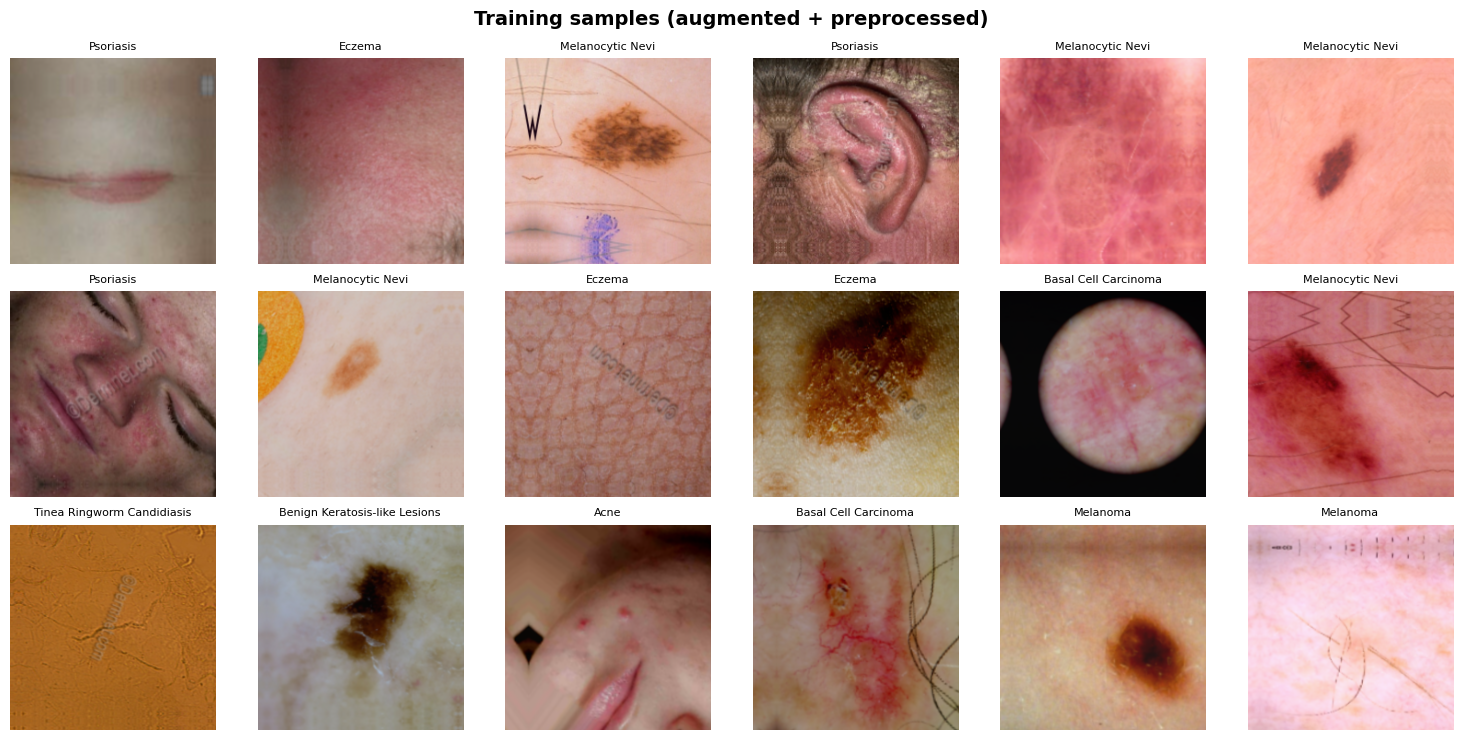

In [10]:
# ============================================================
# SECTION 3 - SAMPLE GRID (post-augmentation, post-preprocess)
# ============================================================

def show_sample_grid(dataset, class_names, rows=3, cols=6, title="Sample images"):
    images, labels = next(iter(dataset))
    labels = labels.numpy()
    imgs   = images.numpy()
    imgs   = imgs - imgs.min()
    imgs   = imgs / (imgs.max() + 1e-7)

    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
    fig.suptitle(title, fontsize=14, fontweight="bold")

    for ax, img, lbl in zip(axes.flat, imgs, labels):
        ax.imshow(img)
        ax.set_title(class_names[lbl], fontsize=8)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_sample_grid(train_ds, class_names, title="Training samples (augmented + preprocessed)")


In [11]:
# ============================================================
# SECTION 4 - MODEL DEFINITION
# ============================================================

def build_model(num_classes, img_size, learning_rate, dropout_rate):
    """
    EfficientNetB0 backbone (ImageNet weights, backbone frozen for Phase 1)
    followed by a regularised classification head.

    The model is compiled once here. Subsequent fine-tuning stages
    call model.compile() only to update the optimizer learning rate
    while preserving the model graph.
    """
    base_model = EfficientNetB0(
        input_shape = (*img_size, 3),
        include_top = False,
        weights     = "imagenet",
    )
    base_model.trainable = False   # frozen for Phase 1

    inputs = tf.keras.Input(shape=(*img_size, 3), name="input_image")
    # training=False keeps backbone BN in inference mode during Phase 1
    x = base_model(inputs, training=False)

    x = layers.GlobalAveragePooling2D(name="gap")(x)
    x = layers.BatchNormalization(name="bn_gap")(x)

    x = layers.Dense(
        512, activation="relu", name="dense_512",
        kernel_regularizer=tf.keras.regularizers.l2(2e-4)
    )(x)
    x = layers.Dropout(dropout_rate, name="dropout_1")(x)

    x = layers.Dense(
        256, activation="relu", name="dense_256",
        kernel_regularizer=tf.keras.regularizers.l2(2e-4)
    )(x)
    x = layers.Dropout(dropout_rate * 0.5, name="dropout_2")(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = tf.keras.Model(inputs, outputs, name="DermaNet_EfficientB0")

    model.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss      = focal_loss,           # Focal Loss replaces cross-entropy,
        metrics   = [
            "accuracy",
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_acc"),
        ],
    )

    return model, base_model


model, base_model = build_model(
    num_classes   = CONFIG["num_classes"],
    img_size      = CONFIG["img_size"],
    learning_rate = 1e-3,
    dropout_rate  = CONFIG["dropout_rate"],
)

model.summary()
print(f"\nTrainable params (Phase 1 head only): "
      f"{sum(np.prod(w.shape) for w in model.trainable_weights):,}")


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "DermaNet_EfficientB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_gap (BatchNormalization)     │ (None, 1280)           │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_512 (Dense)               │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,844,461 (18.48 MB)

 Trainable params: 792,330 (3.02 MB)

 Non-trainable params: 4,052,131 (15.46 MB)


Trainable params (Phase 1 head only): 792,330


In [12]:
# ============================================================
# SECTION 5 - PHASE 1: TRAIN CLASSIFICATION HEAD (FROZEN BACKBONE)
#
# Strategy: freeze the entire backbone and train only the new
# dense head with a cosine-decayed learning rate.
# Cosine decay removes the need for ReduceLROnPlateau in Phase 1
# and prevents oscillation near convergence.
# ============================================================

total_steps_p1 = len(train_ds) * CONFIG["phase1_epochs"]

cosine_decay_p1 = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate = 1e-3,
    decay_steps           = total_steps_p1,
    alpha                 = 1e-6,    # floor LR at end of schedule
)

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=cosine_decay_p1),
    loss      = focal_loss,           # Focal Loss,
    metrics   = [
        "accuracy",
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_acc"),
    ],
)

cb_es_p1 = callbacks.EarlyStopping(
    monitor              = "val_loss",
    patience             = 8,
    restore_best_weights = True,
    verbose              = 1,
)
cb_ckpt_p1 = callbacks.ModelCheckpoint(
    filepath       = "best_phase1.keras",
    monitor        = "val_loss",
    save_best_only = True,
    verbose        = 1,
)

print("Phase 1 - training head with frozen backbone...\n")

history_phase1 = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs          = CONFIG["phase1_epochs"],
    class_weight    = class_weight_dict,
    callbacks       = [cb_es_p1, cb_ckpt_p1],
    verbose         = 1,
)

PHASE1_LEN = len(history_phase1.history["accuracy"])
print(f"\nPhase 1 complete ({PHASE1_LEN} epochs).")
print(f"  Best val_loss : {min(history_phase1.history['val_loss']):.4f}")


Phase 1 - training head with frozen backbone...

Epoch 1/30


I0000 00:00:1778318276.408110     130 service.cc:152] XLA service 0x785524001f80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778318276.408156     130 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778318276.408161     130 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778318281.258651     130 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-09 09:18:10.756265: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 09:18:10.913619: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 09:18:11.324132: E external/local_xl

316/317 ━━━━━━━━━━━━━━━━━━━━ 0s 636ms/step - accuracy: 0.4729 - loss: 0.5478 - top3_acc: 0.7879

2026-05-09 09:21:48.561985: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 09:21:48.706499: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 09:21:49.056815: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 09:21:49.199541: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 09:21:49.340849: E external/local_xla/xla/stream_

317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - accuracy: 0.4730 - loss: 0.5475 - top3_acc: 0.7881

2026-05-09 09:22:18.650401: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 09:22:18.802360: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 09:22:19.180736: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 09:22:19.323666: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 09:22:20.109975: E external/local_xla/xla/stream_


Epoch 1: val_loss improved from inf to 0.32968, saving model to best_phase1.keras
317/317 ━━━━━━━━━━━━━━━━━━━━ 280s 774ms/step - accuracy: 0.4732 - loss: 0.5473 - top3_acc: 0.7883 - val_accuracy: 0.6295 - val_loss: 0.3297 - val_top3_acc: 0.9187
Epoch 2/30
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 655ms/step - accuracy: 0.5895 - loss: 0.3866 - top3_acc: 0.8897
Epoch 2: val_loss improved from 0.32968 to 0.28515, saving model to best_phase1.keras
317/317 ━━━━━━━━━━━━━━━━━━━━ 216s 682ms/step - accuracy: 0.5895 - loss: 0.3865 - top3_acc: 0.8897 - val_accuracy: 0.6468 - val_loss: 0.2851 - val_top3_acc: 0.9260
Epoch 3/30
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 645ms/step - accuracy: 0.6054 - loss: 0.3378 - top3_acc: 0.9051
Epoch 3: val_loss improved from 0.28515 to 0.25062, saving model to best_phase1.keras
317/317 ━━━━━━━━━━━━━━━━━━━━ 213s 672ms/step - accuracy: 0.6055 - loss: 0.3377 - top3_acc: 0.9051 - val_accuracy: 0.6673 - val_loss: 0.2506 - val_top3_acc: 0.9297
Epoch 4/30
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s

In [13]:
# ============================================================
# SECTION 6 - PHASE 2: GRADUAL FINE-TUNING
#
# Design decisions (production-grade):
#
# 1. SINGLE checkpoint path (CONFIG["model_path"]).
#    Each stage overwrites the previous best only when val_loss
#    actually improves, so the file always holds the best
#    checkpoint seen across all stages.
#
# 2. NO optimizer state bleed between stages.
#    A new Adam instance is created at each stage. This is
#    intentional: carrying accumulated momentum/variance from a
#    higher-LR stage into a lower-LR stage causes the optimizer
#    to make over-sized updates in the first few steps.
#
# 3. BatchNormalization layers ALWAYS remain frozen.
#    Unfreezing BN during fine-tuning destroys the running mean
#    and variance accumulated on ImageNet, which destabilises
#    training on smaller medical datasets.
#
# 4. Cumulative unfreezing: each stage opens MORE of the
#    backbone (20% -> 50% -> 75%). Earlier-stage weights are
#    not re-frozen between stages.
#
# 5. Learning rate decreases with each stage to protect the
#    low-level features in deeper (earlier) backbone layers.
#
# 6. EarlyStopping patience is kept tight (4-5 epochs) in
#    fine-tuning because the model should converge quickly
#    given the already-trained head from Phase 1.
# ============================================================

def set_backbone_trainability(base_model, unfreeze_fraction: float):
    """
    Unfreeze the top `unfreeze_fraction` of backbone layers.
    BatchNormalization layers are always kept frozen regardless
    of their position, to preserve their running statistics.

    Args:
        base_model       : the EfficientNetB0 base model
        unfreeze_fraction: float in (0, 1], fraction of layers to unfreeze
    """
    total  = len(base_model.layers)
    freeze = total - max(1, int(total * unfreeze_fraction))

    base_model.trainable = True
    for i, layer in enumerate(base_model.layers):
        if i < freeze:
            layer.trainable = False
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False   # always frozen, overrides position rule

    n_trainable = sum(1 for l in base_model.layers if l.trainable)
    n_bn        = sum(1 for l in base_model.layers
                      if isinstance(l, layers.BatchNormalization))
    print(f"  Backbone layers  : {total}")
    print(f"  Frozen by pos    : {freeze}")
    print(f"  BN (always frozen): {n_bn}")
    print(f"  Trainable        : {n_trainable}")


# Fine-tuning stages: (unfreeze_fraction, learning_rate, max_epochs, es_patience)
# Fractions are cumulative: each stage opens more of the backbone.
FINE_TUNE_STAGES = [
    (0.20, 1e-5,  8,  4),   # stage 1: top 20% of backbone
    (0.50, 5e-6,  8,  4),   # stage 2: top 50% of backbone
    (0.75, 2e-6, 10,  5),   # stage 3: top 75% of backbone
]

history_phase2_stages = []

for stage_idx, (frac, lr, max_ep, patience) in enumerate(FINE_TUNE_STAGES, start=1):
    print(f"\n--- Fine-tune stage {stage_idx} / {len(FINE_TUNE_STAGES)} ---")
    print(f"  Unfreezing top {frac*100:.0f}% of backbone  |  lr={lr}")

    set_backbone_trainability(base_model, frac)

    # Recompile with a fresh optimizer to avoid stale momentum from previous stage.
    # The model graph and weights are preserved; only the optimizer state resets.
    model.compile(
        optimizer = tf.keras.optimizers.Adam(learning_rate=lr),
        loss      = focal_loss,           # Focal Loss,
        metrics   = [
            "accuracy",
            tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top3_acc"),
        ],
    )

    # Single checkpoint path: only the global best is kept.
    # ModelCheckpoint uses save_best_only=True with the same path across all
    # stages, so the file is only overwritten when val_loss strictly improves.
    cb_es = callbacks.EarlyStopping(
        monitor              = "val_loss",
        patience             = patience,
        restore_best_weights = True,
        verbose              = 1,
    )
    cb_ckpt = callbacks.ModelCheckpoint(
        filepath       = CONFIG["model_path"],   # single shared path
        monitor        = "val_loss",
        save_best_only = True,
        verbose        = 1,
    )

    h = model.fit(
        train_ds,
        validation_data = val_ds,
        epochs          = max_ep,
        class_weight    = class_weight_dict,
        callbacks       = [cb_es, cb_ckpt],
        verbose         = 1,
    )
    history_phase2_stages.append(h)

    best_val = min(h.history["val_loss"])
    print(f"Stage {stage_idx} done. Best val_loss this stage: {best_val:.4f}")

print(f"\nAll fine-tune stages complete.")
print(f"Best model (global) saved -> {CONFIG['model_path']}")



--- Fine-tune stage 1 / 3 ---
  Unfreezing top 20% of backbone  |  lr=1e-05
  Backbone layers  : 238
  Frozen by pos    : 191
  BN (always frozen): 49
  Trainable        : 37
Epoch 1/8
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 682ms/step - accuracy: 0.7279 - loss: 0.1482 - top3_acc: 0.9593
Epoch 1: val_loss improved from inf to 0.12563, saving model to derma_model.keras
317/317 ━━━━━━━━━━━━━━━━━━━━ 267s 746ms/step - accuracy: 0.7279 - loss: 0.1482 - top3_acc: 0.9593 - val_accuracy: 0.7385 - val_loss: 0.1256 - val_top3_acc: 0.9525
Epoch 2/8
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 651ms/step - accuracy: 0.7404 - loss: 0.1437 - top3_acc: 0.9603
Epoch 2: val_loss improved from 0.12563 to 0.12434, saving model to derma_model.keras
317/317 ━━━━━━━━━━━━━━━━━━━━ 215s 678ms/step - accuracy: 0.7404 - loss: 0.1437 - top3_acc: 0.9603 - val_accuracy: 0.7449 - val_loss: 0.1243 - val_top3_acc: 0.9523
Epoch 3/8
317/317 ━━━━━━━━━━━━━━━━━━━━ 0s 647ms/step - accuracy: 0.7341 - loss: 0.1449 - top3_acc: 0.9619
Epoch 3: val

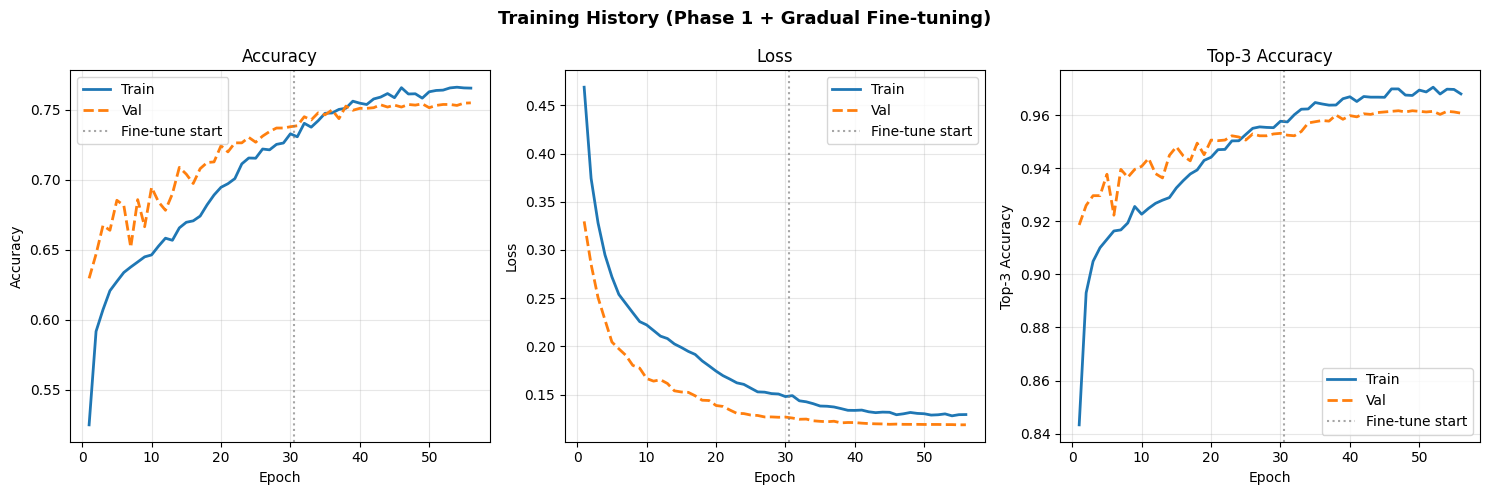

Curves saved -> training_curves.png


In [14]:
# ============================================================
# SECTION 7 - TRAINING CURVES
# ============================================================

def merge_histories(*histories):
    """Concatenate Keras History objects or raw dicts into one dict."""
    merged = {}
    for h in histories:
        src = h.history if hasattr(h, "history") else h
        for key, vals in src.items():
            merged.setdefault(key, []).extend(vals)
    return merged


def plot_history(history_dict, phase1_len=None):
    n_epochs     = len(history_dict["accuracy"])
    epochs_range = range(1, n_epochs + 1)
    has_top3     = "top3_acc" in history_dict
    n_plots      = 3 if has_top3 else 2

    fig, axes = plt.subplots(1, n_plots, figsize=(n_plots * 5, 5))
    fig.suptitle("Training History (Phase 1 + Gradual Fine-tuning)",
                 fontsize=13, fontweight="bold")

    def add_boundary(ax):
        if phase1_len is not None:
            ax.axvline(x=phase1_len + 0.5, color="gray", linestyle=":",
                       alpha=0.7, label="Fine-tune start")

    axes[0].plot(epochs_range, history_dict["accuracy"],     label="Train", lw=2)
    axes[0].plot(epochs_range, history_dict["val_accuracy"], label="Val",   lw=2, ls="--")
    add_boundary(axes[0])
    axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy"); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_range, history_dict["loss"],     label="Train", lw=2)
    axes[1].plot(epochs_range, history_dict["val_loss"], label="Val",   lw=2, ls="--")
    add_boundary(axes[1])
    axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss"); axes[1].legend(); axes[1].grid(alpha=0.3)

    if has_top3:
        axes[2].plot(epochs_range, history_dict["top3_acc"],     label="Train", lw=2)
        axes[2].plot(epochs_range, history_dict["val_top3_acc"], label="Val",   lw=2, ls="--")
        add_boundary(axes[2])
        axes[2].set_title("Top-3 Accuracy"); axes[2].set_xlabel("Epoch")
        axes[2].set_ylabel("Top-3 Accuracy"); axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150)
    plt.show()
    print("Curves saved -> training_curves.png")


merged = merge_histories(history_phase1, *history_phase2_stages)
plot_history(merged, phase1_len=PHASE1_LEN)


Best model loaded from 'derma_model_patched.keras'

──────────────────────────────────────────────────
  Validation : loss: 0.7360  compile_metrics: 0.7546
  Test       : loss: 0.7433  compile_metrics: 0.7479
──────────────────────────────────────────────────


2026-05-09 12:53:00.059164: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 12:53:00.202826: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 12:53:00.550558: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 12:53:00.691939: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 12:53:01.493837: E external/local_xla/xla/stream_


Classification Report:

                               precision    recall  f1-score   support

                         Acne     0.8201    0.8876    0.8525       267
         Basal Cell Carcinoma     0.8195    0.9297    0.8711       498
Benign Keratosis-like Lesions     0.7364    0.5641    0.6388       312
                       Eczema     0.5850    0.5864    0.5857       440
             Melanocytic Nevi     0.8491    0.9322    0.8887      1195
                     Melanoma     0.9385    0.7134    0.8106       471
                    Psoriasis     0.5319    0.4058    0.4604       308
         Seborrheic Keratoses     0.6227    0.7329    0.6733       277
   Tinea Ringworm Candidiasis     0.5880    0.5742    0.5810       256
              Warts Molluscum     0.5754    0.5918    0.5835       316

                     accuracy                         0.7479      4340
                    macro avg     0.7067    0.6918    0.6946      4340
                 weighted avg     0.7465    0.7479

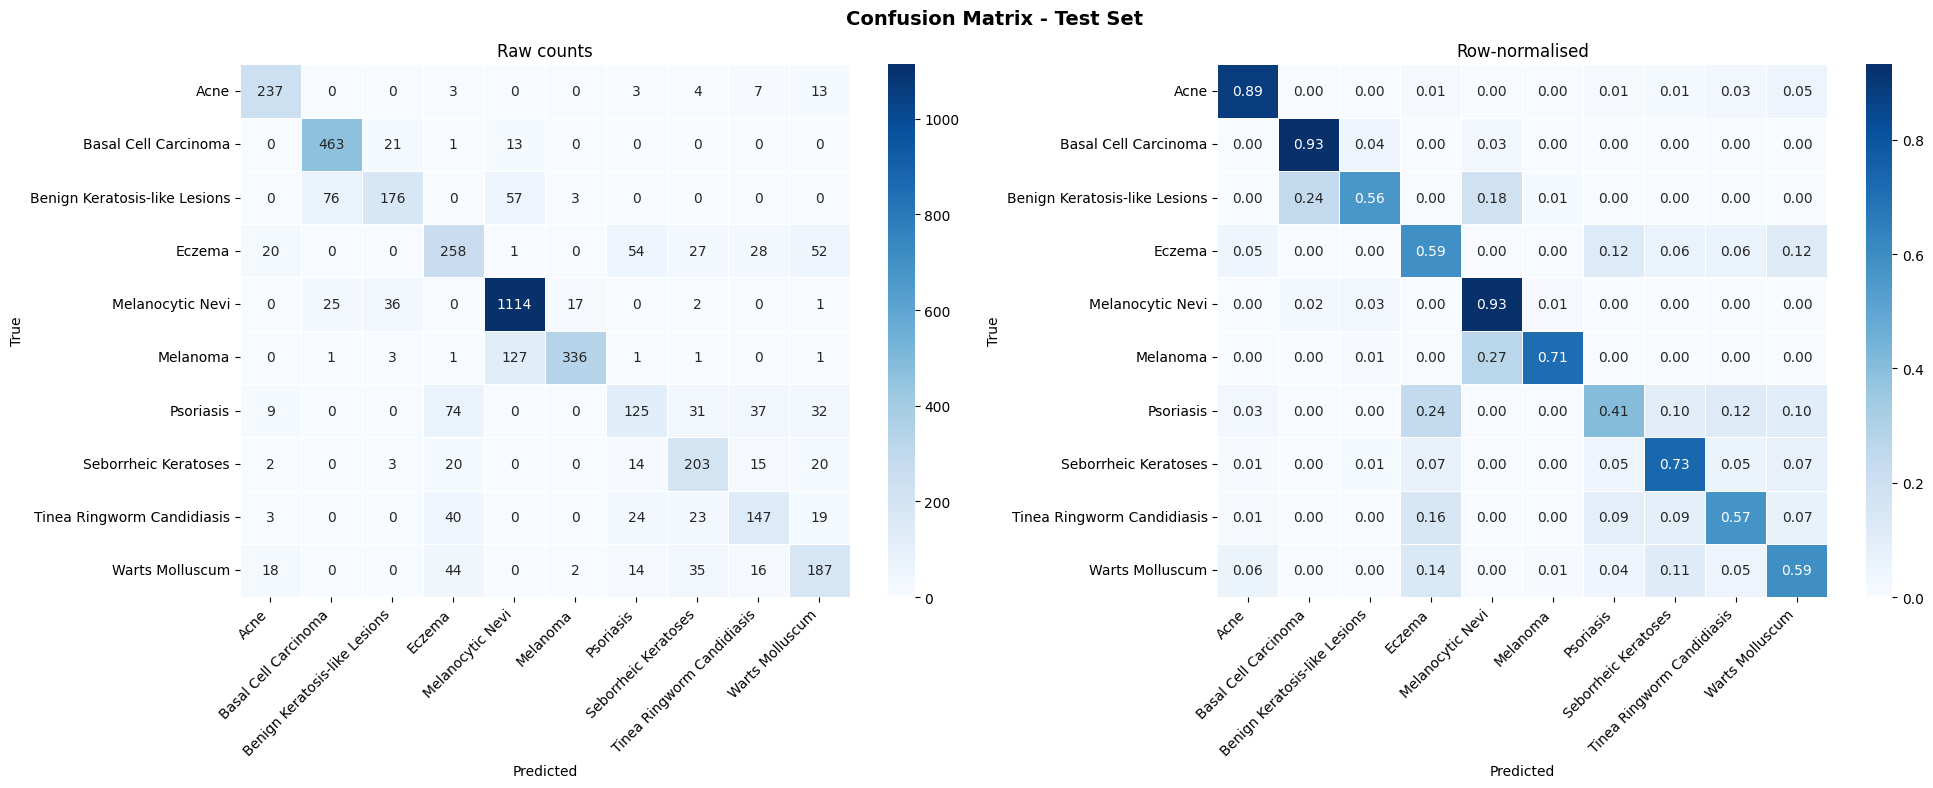

Confusion matrix saved -> confusion_matrix.png


In [17]:
# ============================================================
# SECTION 8 - EVALUATION
# Load the best checkpoint (may be from any fine-tune stage).
# ============================================================
import zipfile, json

model_path   = CONFIG["model_path"]
patched_path = "derma_model_patched.keras"

# Patch: حذف compile_config عشان SparseFocalLoss
with zipfile.ZipFile(model_path, "r") as zin:
    config_dict = json.loads(zin.read("config.json"))

config_dict.pop("compile_config", None)

with zipfile.ZipFile(model_path, "r") as zin, \
     zipfile.ZipFile(patched_path, "w", zipfile.ZIP_DEFLATED) as zout:
    for item in zin.infolist():
        if item.filename == "config.json":
            zout.writestr(item, json.dumps(config_dict))
        else:
            zout.writestr(item, zin.read(item.filename))

best_model = tf.keras.models.load_model(patched_path, compile=False)
print(f"Best model loaded from '{patched_path}'")

# Compile يدوي عشان evaluate يشتغل
best_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

# Compute val and test metrics
val_results  = best_model.evaluate(val_ds,  verbose=0)
test_results = best_model.evaluate(test_ds, verbose=0)
metric_names = best_model.metrics_names

print(f"\n{'─' * 50}")
print("  Validation :", "  ".join(f"{n}: {v:.4f}"
      for n, v in zip(metric_names, val_results)))
print("  Test       :", "  ".join(f"{n}: {v:.4f}"
      for n, v in zip(metric_names, test_results)))
print(f"{'─' * 50}")

def get_predictions(model, dataset):
    """Return (y_true, y_pred) arrays from a dataset."""
    y_true, y_pred = [], []
    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())
    return np.array(y_true), np.array(y_pred)

y_true, y_pred = get_predictions(best_model, test_ds)
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

def plot_confusion_matrix(y_true, y_pred, class_names):
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))
    fig.suptitle("Confusion Matrix - Test Set", fontsize=14, fontweight="bold")
    for ax, data, fmt, title in zip(
        axes,
        [cm, cm_norm],
        ["d", ".2f"],
        ["Raw counts", "Row-normalised"],
    ):
        sns.heatmap(data, annot=True, fmt=fmt, cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names,
                    linewidths=0.5, ax=ax)
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Predicted", fontsize=10)
        ax.set_ylabel("True",      fontsize=10)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150)
    plt.show()
    print("Confusion matrix saved -> confusion_matrix.png")

plot_confusion_matrix(y_true, y_pred, class_names)

In [21]:
# ============================================================
# SECTION 9 - SAVE MODEL
# ============================================================


best_model.save(CONFIG["model_path"])
print(f"Model saved as '{CONFIG['model_path']}'")

best_model.save_weights("derma_model.weights.h5")
print("Weights saved as 'derma_model.weights.h5'")

Model saved as 'derma_model.keras'
Weights saved as 'derma_model.weights.h5'


Single-pass:


2026-05-09 12:57:13.538153: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 12:57:13.673695: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 12:57:14.481332: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-09 12:57:14.616757: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  True : Acne
  Pred : Acne  (95.9%)

TTA (8 passes):
  True : Acne
  Pred : Acne  (95.4%)
    Acne                                     95.4%
    Warts Molluscum                          2.9%
    Eczema                                   1.0%


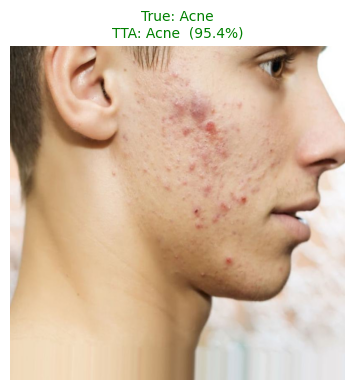

In [22]:
# ============================================================
# SECTION 10 - INFERENCE WITH TEST-TIME AUGMENTATION (TTA)
#
# TTA runs N forward passes over augmented versions of the
# same image, then averages the softmax probabilities.
# This reduces prediction variance at the cost of N x latency.
# Typical gain: +1-2% accuracy over single-pass inference.
# ============================================================

def predict_image(image_path, model=None, img_size=(224, 224), top_k=3):
    """
    Single-pass prediction. Fast but higher variance.
    """
    if model is None:
        model = best_model

    img   = load_img(image_path, target_size=img_size)
    arr   = img_to_array(img)
    arr   = efficientnet_preprocess(arr)
    batch = np.expand_dims(arr, axis=0)

    probs    = model.predict(batch, verbose=0)[0]
    pred_idx = int(np.argmax(probs))

    top_indices = np.argsort(probs)[::-1][:top_k]
    top_k_list  = [
        {"disease": idx2label[i], "confidence": round(float(probs[i]), 4)}
        for i in top_indices
    ]
    return {
        "disease"    : idx2label[pred_idx],
        "confidence" : round(float(probs[pred_idx]), 4),
        "top_k"      : top_k_list,
    }


# TTA augmentation: conservative transforms safe for dermatology images.
_tta_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.15),
    layers.RandomContrast(0.10),
], name="tta_augmentation")


def predict_image_tta(image_path, model=None, img_size=(224, 224),
                      top_k=3, n_passes=8):
    """
    Test-time augmentation prediction.
    Pass 1 is always the original (unaugmented) image.
    Passes 2..n_passes use random augmentation.
    The softmax outputs are averaged before taking argmax.
    """
    if model is None:
        model = best_model

    img        = load_img(image_path, target_size=img_size)
    arr        = img_to_array(img)
    arr        = efficientnet_preprocess(arr)
    arr_tensor = tf.expand_dims(arr, axis=0)

    all_probs = [model.predict(arr_tensor, verbose=0)[0]]   # pass 1: no aug

    for _ in range(n_passes - 1):
        aug = _tta_aug(arr_tensor, training=True)
        all_probs.append(model.predict(aug, verbose=0)[0])

    mean_probs  = np.mean(all_probs, axis=0)
    pred_idx    = int(np.argmax(mean_probs))
    top_indices = np.argsort(mean_probs)[::-1][:top_k]
    top_k_list  = [
        {"disease": idx2label[i], "confidence": round(float(mean_probs[i]), 4)}
        for i in top_indices
    ]
    return {
        "disease"    : idx2label[pred_idx],
        "confidence" : round(float(mean_probs[pred_idx]), 4),
        "top_k"      : top_k_list,
        "tta_passes" : n_passes,
    }


# Demo
sample_row = test_df.sample(1, random_state=99).iloc[0]

print("Single-pass:")
r1 = predict_image(sample_row["path"])
print(f"  True : {sample_row['label']}")
print(f"  Pred : {r1['disease']}  ({r1['confidence']*100:.1f}%)")

print("\nTTA (8 passes):")
r2 = predict_image_tta(sample_row["path"], n_passes=8)
print(f"  True : {sample_row['label']}")
print(f"  Pred : {r2['disease']}  ({r2['confidence']*100:.1f}%)")
for item in r2["top_k"]:
    print(f"    {item['disease']:40s} {item['confidence']*100:.1f}%")

img = Image.open(sample_row["path"])
plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis("off")
color = "green" if sample_row["label"] == r2["disease"] else "red"
plt.title(
    f"True: {sample_row['label']}\nTTA: {r2['disease']}  ({r2['confidence']*100:.1f}%)",
    fontsize=10, color=color,
)
plt.tight_layout()
plt.show()


In [23]:
# ============================================================
# SECTION 11 - FASTAPI ENDPOINT (run as separate app.py)
#
# Start : uvicorn app:app --reload --port 8000
# Test  : curl -X POST http://localhost:8000/predict -F "file=@image.jpg"
# Docs  : http://localhost:8000/docs
# ============================================================

FASTAPI_CODE = '''
import io
import numpy as np
from contextlib import asynccontextmanager

from fastapi import FastAPI, File, UploadFile, HTTPException
from fastapi.responses import JSONResponse
import tensorflow as tf
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from PIL import Image

MODEL_PATH  = "derma_model.keras"
IMG_SIZE    = (224, 224)
CLASS_NAMES = [
    "Acne",
    "Basal Cell Carcinoma",
    "Benign Keratosis-like Lesions",
    "Eczema",                          # merged: Atopic Dermatitis + Eczema
    "Melanocytic Nevi",
    "Melanoma",
    "Psoriasis",
    "Seborrheic Keratoses",
    "Tinea Ringworm Candidiasis",
    "Warts Molluscum",
]  # 10 classes (Atopic Dermatitis merged into Eczema)

model = None

@asynccontextmanager
async def lifespan(app: FastAPI):
    global model
    model = tf.keras.models.load_model(MODEL_PATH)
    print(f"Model loaded from {MODEL_PATH}")
    yield

app = FastAPI(
    title       = "Dermatology AI API",
    description = "EfficientNetB0-based skin disease classifier",
    version     = "2.0.0",
    lifespan    = lifespan,
)


def preprocess(image_bytes: bytes) -> np.ndarray:
    img = Image.open(io.BytesIO(image_bytes)).convert("RGB")
    img = img.resize(IMG_SIZE)
    arr = np.array(img, dtype=np.float32)
    arr = efficientnet_preprocess(arr)
    return np.expand_dims(arr, axis=0)


@app.post("/predict")
async def predict(file: UploadFile = File(...)):
    if not file.content_type.startswith("image/"):
        raise HTTPException(status_code=400, detail="File must be an image.")
    image_bytes = await file.read()
    try:
        batch = preprocess(image_bytes)
        probs = model.predict(batch, verbose=0)[0]
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"Prediction error: {e}")

    pred_idx   = int(np.argmax(probs))
    confidence = float(probs[pred_idx])
    top3 = [
        {"disease": CLASS_NAMES[i], "confidence": round(float(probs[i]), 4)}
        for i in np.argsort(probs)[::-1][:3]
    ]
    return JSONResponse({
        "disease"    : CLASS_NAMES[pred_idx],
        "confidence" : round(confidence, 4),
        "top_3"      : top3,
    })


@app.get("/health")
def health():
    return {"status": "ok", "model_loaded": model is not None}
'''

with open("app.py", "w") as fh:
    fh.write(FASTAPI_CODE.strip())

print("FastAPI app written -> app.py")
print("  Install : pip install fastapi uvicorn python-multipart")
print("  Run     : uvicorn app:app --reload --port 8000")


FastAPI app written -> app.py
  Install : pip install fastapi uvicorn python-multipart
  Run     : uvicorn app:app --reload --port 8000
